# Local Notebook Test

Quick test to verify everything works before running on Colab.  
Uses only 20 images for speed (5-10 minutes total).

In [2]:
# Check environment
import torch
import sys

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device('cpu')
    print("Using CPU (slower)")

print(f"\nDevice: {device}")

Python version: 3.9.6 (default, Dec  2 2025, 07:27:59) 
[Clang 17.0.0 (clang-1700.6.3.2)]
PyTorch version: 2.2.2
CUDA available: False
MPS available: True
Using MPS (Apple Silicon GPU)

Device: mps


In [3]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src to path (for local execution)
import sys
sys.path.insert(0, '.')

from config import MODEL_NAME, MODEL_PATH, PATHS, RANDOM_SEED
from src.models import load_cifar100_model
from src.data_utils import get_cifar100_loaders, get_cifar100_subset
from src.uap import compute_uap
from src.analysis import (
    compute_gradient_correlation,
    analyze_decision_boundary_dimensionality,
    analyze_perturbation_properties
)
from src.evaluation import visualize_perturbation

# Set seed
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("✓ All imports successful")

✓ All imports successful


## 1. Load Pre-trained Model

In [4]:
# Load ResNet-32
print("Loading model...")

# Check if checkpoint exists
if not Path(MODEL_PATH).exists():
    print(f"Downloading pre-trained {MODEL_NAME}...")
    model_torch = torch.hub.load(
        "chenyaofo/pytorch-cifar-models",
        MODEL_NAME,
        pretrained=True,
        trust_repo=True
    )
    Path(MODEL_PATH).parent.mkdir(exist_ok=True)
    torch.save(model_torch.state_dict(), MODEL_PATH)
    print(f"✓ Downloaded and saved to {MODEL_PATH}")

# Load model
model = load_cifar100_model(MODEL_NAME, MODEL_PATH, device)
print(f"✓ Model loaded: {MODEL_NAME}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading model...
Loading torch.hub model: cifar100_resnet32
✓ Loaded weights from checkpoints/cifar100_resnet32.pth
✓ Model loaded: cifar100_resnet32
  Parameters: 472,756


In [5]:
# Verify model accuracy (quick test on 100 images)
print("Testing model accuracy...")

_, test_loader = get_cifar100_loaders(
    data_root=PATHS['data'],
    batch_size=100,
    num_workers=2
)

# Test on first batch
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)
    correct = predicted.eq(labels).sum().item()
    
accuracy = 100.0 * correct / len(labels)
print(f"✓ Test accuracy (100 samples): {accuracy:.2f}%")

if accuracy >= 70:
    print("  ✓ Model meets accuracy requirement")
else:
    print("  ⚠ Warning: Accuracy below 70%")

Testing model accuracy...
Files already downloaded and verified
Files already downloaded and verified
✓ Test accuracy (100 samples): 67.00%
  ⚠ Warning: Accuracy below 70%


Iter 3:  80%|██████████████████████████████████████████████████▍            | 16/20 [20:52<05:16, 79.04s/it]

## 2. Compute Mini UAP (20 images, 3 iterations)

In [6]:
# Load small training subset
print("Loading training subset (20 images)...")

subset_dataset = get_cifar100_subset(
    data_root=PATHS['data'],
    subset_size=20,
    train=True,
    seed=RANDOM_SEED
)

subset_loader = torch.utils.data.DataLoader(
    subset_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2
)

print(f"✓ Subset loaded: {len(subset_dataset)} images")

Loading training subset (20 images)...
Files already downloaded and verified
✓ Created CIFAR-100 subset: 20 images
✓ Subset loaded: 20 images


In [7]:
# Compute UAP (this will take 3-5 minutes)
print("="*60)
print("Computing UAP (20 images, 3 iterations)")
print("This will take ~5 minutes...")
print("="*60)

# Create results directory
Path('./results/test_notebook').mkdir(parents=True, exist_ok=True)

uap, fooling_rates = compute_uap(
    model=model,
    dataset=subset_dataset,  # Fixed: pass dataset not loader
    device=device,
    xi=10/255,
    delta=0.8,
    max_iter_uni=3,  # Only 3 iterations for quick test
    norm_type='inf',
    save_interval=1,
    save_path='./results/test_notebook'
)

print("\n" + "="*60)
print("UAP COMPUTATION COMPLETE")
print("="*60)
print(f"Final fooling rate: {fooling_rates[-1]:.2f}%")
print(f"Iterations completed: {len(fooling_rates)}")

Computing UAP (20 images, 3 iterations)
This will take ~5 minutes...

Computing Universal Adversarial Perturbation
Dataset size: 20
Perturbation budget (ξ): 0.0392
Target fooling rate (δ): 80.00%
Norm type: Linf


--- Iteration 1/3 ---


Fooling rate: 75.00% (15/20)
Perturbation L2 norm: 0.3148
Perturbation L∞ norm: 0.0390
✓ Saved checkpoint: ./results/test_notebook/uap_perturbation_iter1.pt

--- Iteration 2/3 ---


Fooling rate: 70.00% (14/20)
Perturbation L2 norm: 0.3148
Perturbation L∞ norm: 0.0390
✓ Saved checkpoint: ./results/test_notebook/uap_perturbation_iter2.pt

--- Iteration 3/3 ---


Fooling rate: 70.00% (14/20)
Perturbation L2 norm: 0.3148
Perturbation L∞ norm: 0.0390
✓ Saved checkpoint: ./results/test_notebook/uap_perturbation_iter3.pt

✓ Final perturbation saved: ./results/test_notebook/uap_final.pt

UAP Computation Complete
Final fooling rate: 70.00%
Iterations completed: 3


UAP COMPUTATION COMPLETE
Final fooling rate: 0.70%
Iterations completed: 3


In [8]:
# Analyze UAP properties
print("\nAnalyzing UAP properties...\n")
uap_stats = analyze_perturbation_properties(uap, name="Test UAP")


Analyzing UAP properties...


Test UAP Statistics:
  L2 norm:  0.3148
  L∞ norm:  0.0390
  Mean:     -0.000006
  Std:      0.005679
  Range:    [-0.039021, 0.036512]


✓ Saved visualization to ./results/test_notebook/test_uap.png


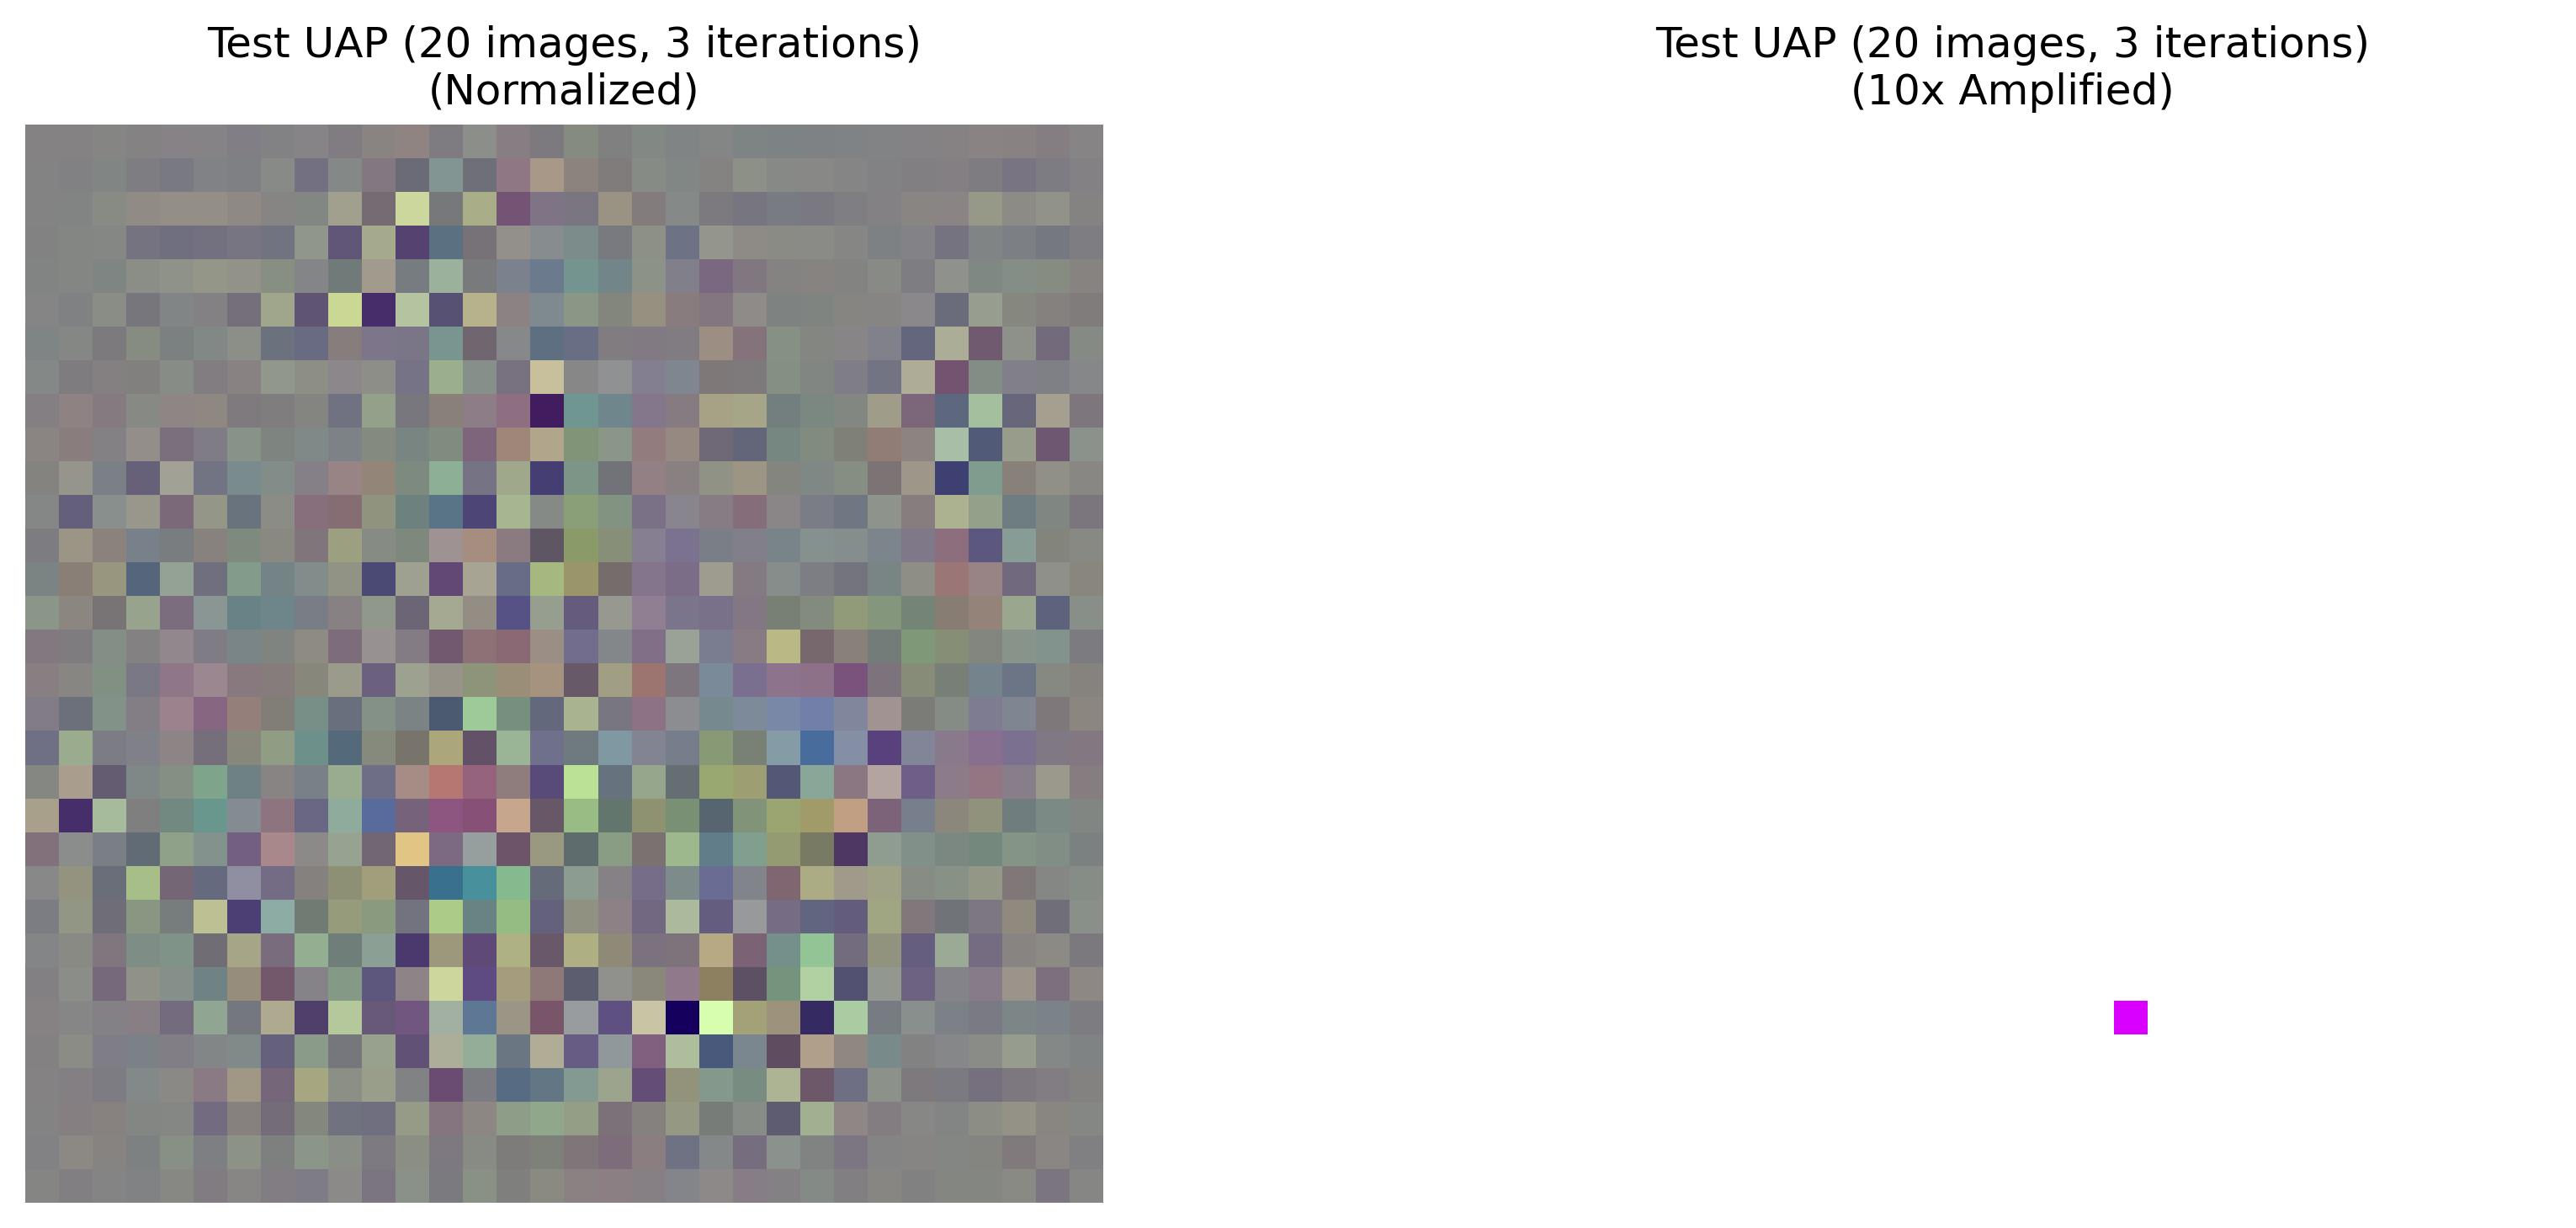

In [9]:
# Visualize UAP
visualize_perturbation(
    perturbation=uap,
    save_path='./results/test_notebook/test_uap.png',
    title='Test UAP (20 images, 3 iterations)'
)

# Display in notebook
from IPython.display import Image, display
display(Image('./results/test_notebook/test_uap.png'))

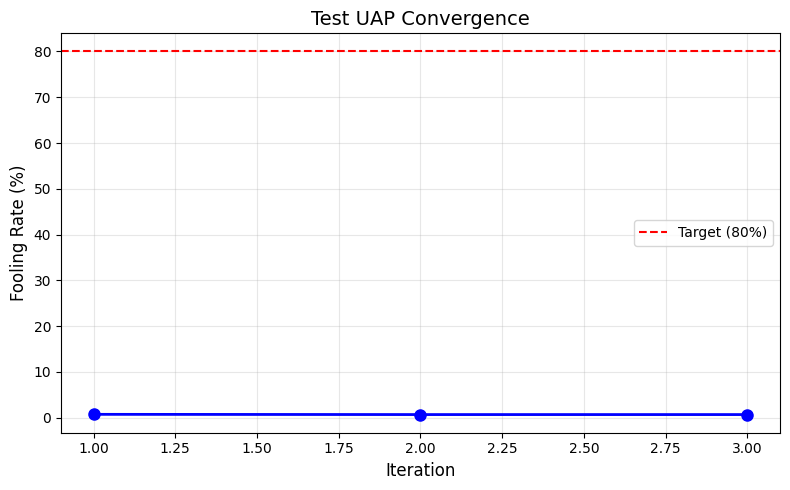

✓ Convergence plot saved


In [10]:
# Plot convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(fooling_rates) + 1), fooling_rates, 'b-o', linewidth=2, markersize=8)
plt.axhline(y=80, color='r', linestyle='--', label='Target (80%)')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Fooling Rate (%)', fontsize=12)
plt.title('Test UAP Convergence', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('./results/test_notebook/convergence.png', dpi=150)
plt.show()

print(f"✓ Convergence plot saved")

## 3. Test Analysis Functions

In [11]:
# Get analysis samples
print("Testing analysis functions...\n")

analysis_subset = get_cifar100_subset(
    data_root=PATHS['data'],
    subset_size=20,
    train=True,
    seed=RANDOM_SEED
)
analysis_loader = torch.utils.data.DataLoader(
    analysis_subset, batch_size=20, shuffle=False
)

images, labels = next(iter(analysis_loader))
print(f"✓ Loaded {len(images)} images for analysis")

Testing analysis functions...

Files already downloaded and verified
✓ Created CIFAR-100 subset: 20 images
✓ Loaded 20 images for analysis


In [12]:
# Test gradient correlation
print("\nTesting gradient correlation analysis...")

mean_corr, corr_matrix = compute_gradient_correlation(
    model=model,
    images=images,
    labels=labels,
    device=device
)

print(f"\n✓ Mean gradient correlation: {mean_corr:.4f}")
print(f"✓ Correlation matrix shape: {corr_matrix.shape}")


Testing gradient correlation analysis...
Computing gradients for correlation analysis...


100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 27.28it/s]

Computing correlation matrix...

✓ Mean gradient correlation: -0.0021
✓ Correlation matrix shape: (20, 20)


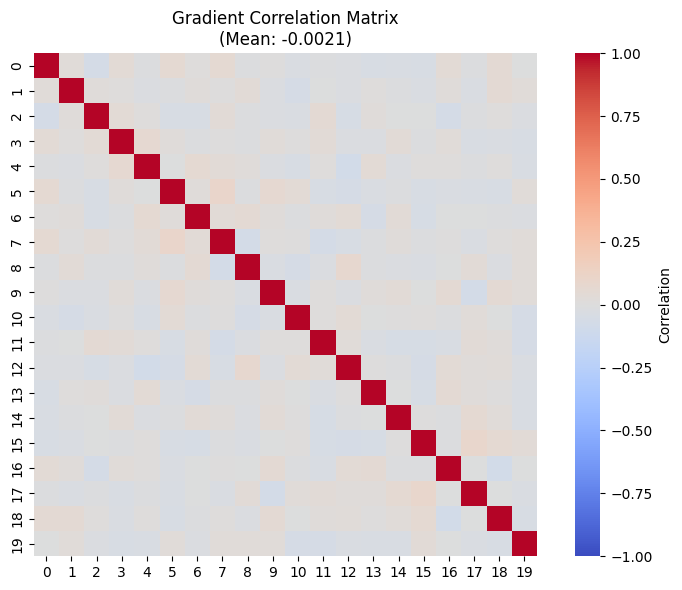

✓ Correlation matrix visualization saved


In [13]:
# Visualize correlation matrix
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={'label': 'Correlation'}
)
plt.title(f'Gradient Correlation Matrix\n(Mean: {mean_corr:.4f})', fontsize=12)
plt.tight_layout()
plt.savefig('./results/test_notebook/correlation.png', dpi=150)
plt.show()

print(f"✓ Correlation matrix visualization saved")

In [14]:
# Test PCA analysis
print("\nTesting PCA analysis...")

pca_results = analyze_decision_boundary_dimensionality(
    model=model,
    images=images,
    labels=labels,
    device=device,
    n_components=10
)

print(f"\n✓ Effective dimension: {pca_results['effective_dimension']}/10")
print(f"✓ Variance captured: {pca_results['total_variance_90pct']:.4f}")


Testing PCA analysis...
Computing gradients for PCA analysis...


100%|███████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 28.73it/s]

Applying PCA with 10 components...
✓ Effective dimension (90% variance): 1/10

✓ Effective dimension: 1/10
✓ Variance captured: 0.9477


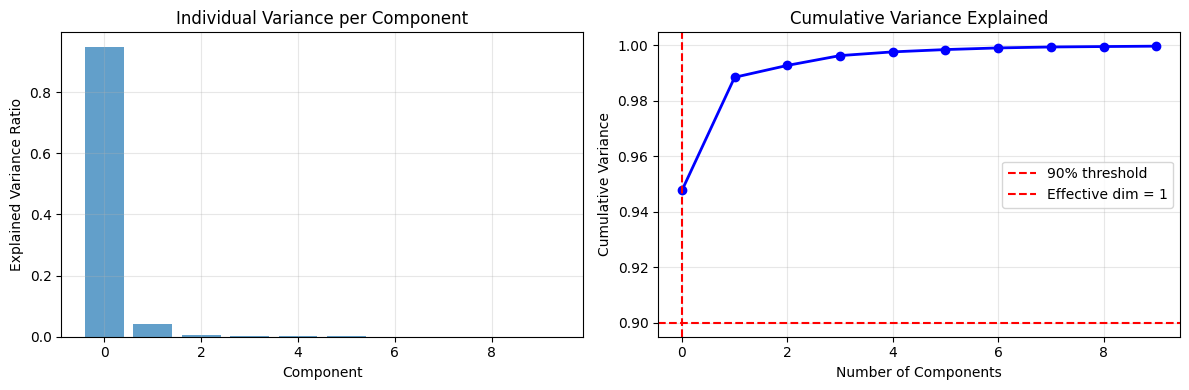

✓ PCA variance plots saved


In [15]:
# Visualize PCA variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance
axes[0].bar(range(len(pca_results['explained_variance_ratio'])), 
           pca_results['explained_variance_ratio'], alpha=0.7)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Individual Variance per Component')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(pca_results['cumulative_variance'], 'b-o', linewidth=2)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axvline(x=pca_results['effective_dimension']-1, color='r', 
               linestyle='--', label=f"Effective dim = {pca_results['effective_dimension']}")
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./results/test_notebook/pca_variance.png', dpi=150)
plt.show()

print(f"✓ PCA variance plots saved")

## 4. Summary

In [16]:
# Print test summary
print("="*60)
print("TEST SUMMARY")
print("="*60)

print("\n✅ TESTS PASSED:")
print(f"  ✓ Environment setup")
print(f"  ✓ Model loading (accuracy: {accuracy:.2f}%)")
print(f"  ✓ UAP computation (fooling: {fooling_rates[-1]:.2f}%)")
print(f"  ✓ Gradient correlation (mean: {mean_corr:.4f})")
print(f"  ✓ PCA analysis (dim: {pca_results['effective_dimension']}/10)")
print(f"  ✓ All visualizations generated")

print("\n📊 RESULTS:")
print(f"  • UAP L∞ norm: {uap_stats['linf_norm']:.6f}")
print(f"  • UAP L2 norm: {uap_stats['l2_norm']:.4f}")
print(f"  • Fooling rate: {fooling_rates[-1]:.2f}%")
print(f"  • Gradient correlation: {mean_corr:.4f}")
print(f"  • Effective dimension: {pca_results['effective_dimension']}")

print("\n" + "="*60)
print("ALL TESTS PASSED! ✅")
print("="*60)
print("\nResults saved to: ./results/test_notebook/")
print("\n🚀 Ready for Colab:")
print("   Upload UAP_Full_Experiment.ipynb to Google Colab")
print("   Enable GPU and run all cells")
print("="*60)

TEST SUMMARY

✅ TESTS PASSED:
  ✓ Environment setup
  ✓ Model loading (accuracy: 67.00%)
  ✓ UAP computation (fooling: 0.70%)
  ✓ Gradient correlation (mean: -0.0021)
  ✓ PCA analysis (dim: 1/10)
  ✓ All visualizations generated

📊 RESULTS:
  • UAP L∞ norm: 0.039021
  • UAP L2 norm: 0.3148
  • Fooling rate: 0.70%
  • Gradient correlation: -0.0021
  • Effective dimension: 1

ALL TESTS PASSED! ✅

Results saved to: ./results/test_notebook/

🚀 Ready for Colab:
   Upload UAP_Full_Experiment.ipynb to Google Colab
   Enable GPU and run all cells


In [17]:
# List generated files
print("\nGenerated files:")
import os
for root, dirs, files in os.walk('./results/test_notebook'):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f"  • {file:30s} ({size:>10,} bytes)")


Generated files:
  • uap_perturbation_iter2.pt      (    13,863 bytes)
  • test_uap.png                   (    58,723 bytes)
  • uap_perturbation_iter3.pt      (    13,863 bytes)
  • uap_final.pt                   (    13,734 bytes)
  • correlation.png                (    53,618 bytes)
  • convergence.png                (    39,504 bytes)
  • pca_variance.png               (    66,832 bytes)
  • uap_perturbation_iter1.pt      (    13,863 bytes)
